# 280 GPa. Más duro que el diamante que conoces.

El diamante hexagonal solo se había visto en meteoritos y nadie estaba seguro de que existiera como fase real. Ahora lo sintetizaron en el laboratorio — y resulta que es **más duro** que el diamante cúbico.

---

**Paper:** Xu et al. (2026) — *Nature*
**DOI:** [10.1038/s41586-026-10212-4](https://doi.org/10.1038/s41586-026-10212-4)
**Video:** [Ver en YouTube](https://youtube.com/watch?v=EXoqWqt_aeo)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-03-11-diamante-hexagonal-meteoritos/notebook.ipynb)

## Una historia de meteoritos y controversia

El carbono tiene varias formas de organizarse. La que conocemos es el **diamante cúbico (CD)** — los átomos en una red cúbica centrada en las caras. Pero existe una alternativa: el **diamante hexagonal (HD)**, también llamado lonsdaleíta, donde los átomos se apilan en estructura wurtzita.

Hasta ahora, el HD solo aparecía en fragmentos diminutos de meteoritos que impactaron la Tierra. Algunos investigadores decían que no era real — solo diamante cúbico aplastado por el impacto. Xu y compañía comprimieron grafito pirolítico (HOPG) a alta presión y temperatura, y obtuvieron cristales de HD puro de **escala milimétrica** — los primeros del mundo. Lo verificaron con rayos X y le midieron la dureza.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
DUREZA_CD_REF = 100          # Dureza Vickers del diamante cúbico estándar (GPa, ~10 N)
FUENTE = 'Fuente: Xu et al. (2026), Nature | Source Data del paper'
COLOR_AXIAL = '#2563EB'      # Azul CaM — dirección axial
COLOR_RADIAL = '#DC2626'     # Rojo — dirección radial
COLOR_HOPG = '#D97706'       # Amber — grafito HOPG
COLOR_HD = '#059669'         # Emerald — diamante hexagonal
COLOR_REF = '#BBBBBB'        # Gris — referencia CD

# ── Setup ──
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

BASE = 'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main'
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(f'{BASE}/cam.mplstyle', style_file)
plt.style.use(style_file)

# ── Cargar datos ──
df_dureza = pd.read_csv('datos/dureza_hd.csv')
df_tga = pd.read_csv('datos/estabilidad_termica.csv')
df_xrd = pd.read_csv('datos/xrd_patrones.csv')

print(f"Dureza: {len(df_dureza)} mediciones ({df_dureza['direction'].nunique()} direcciones)")
print(f"TGA: {len(df_tga)} puntos (HD + HOPG)")
print(f"XRD: {len(df_xrd)} puntos (downsampled)")

# Resumen dureza
for d in ['axial', 'radial']:
    sub = df_dureza[df_dureza['direction'] == d]
    print(f"\nDureza {d} (HD):")
    for _, r in sub.iterrows():
        print(f"  {r['load_N']:.2f} N: {r['hardness_GPa']:.1f} ± {r['error_GPa']:.1f} GPa")

Dureza: 10 mediciones (2 direcciones)
TGA: 1261 puntos (HD + HOPG)
XRD: 1462 puntos (downsampled)

Dureza axial (HD):
  0.98 N: 270.8 ± 22.0 GPa
  2.94 N: 174.6 ± 13.8 GPa
  4.90 N: 129.7 ± 8.5 GPa
  6.86 N: 121.4 ± 8.8 GPa
  9.80 N: 114.4 ± 6.4 GPa

Dureza radial (HD):
  0.98 N: 279.8 ± 19.4 GPa
  2.94 N: 162.2 ± 13.2 GPa
  4.90 N: 132.5 ± 6.8 GPa
  6.86 N: 113.1 ± 5.5 GPa
  9.80 N: 106.6 ± 5.7 GPa


## ¿Qué tan duro es?

Midieron la dureza Vickers del diamante hexagonal a distintas cargas. Veamos.

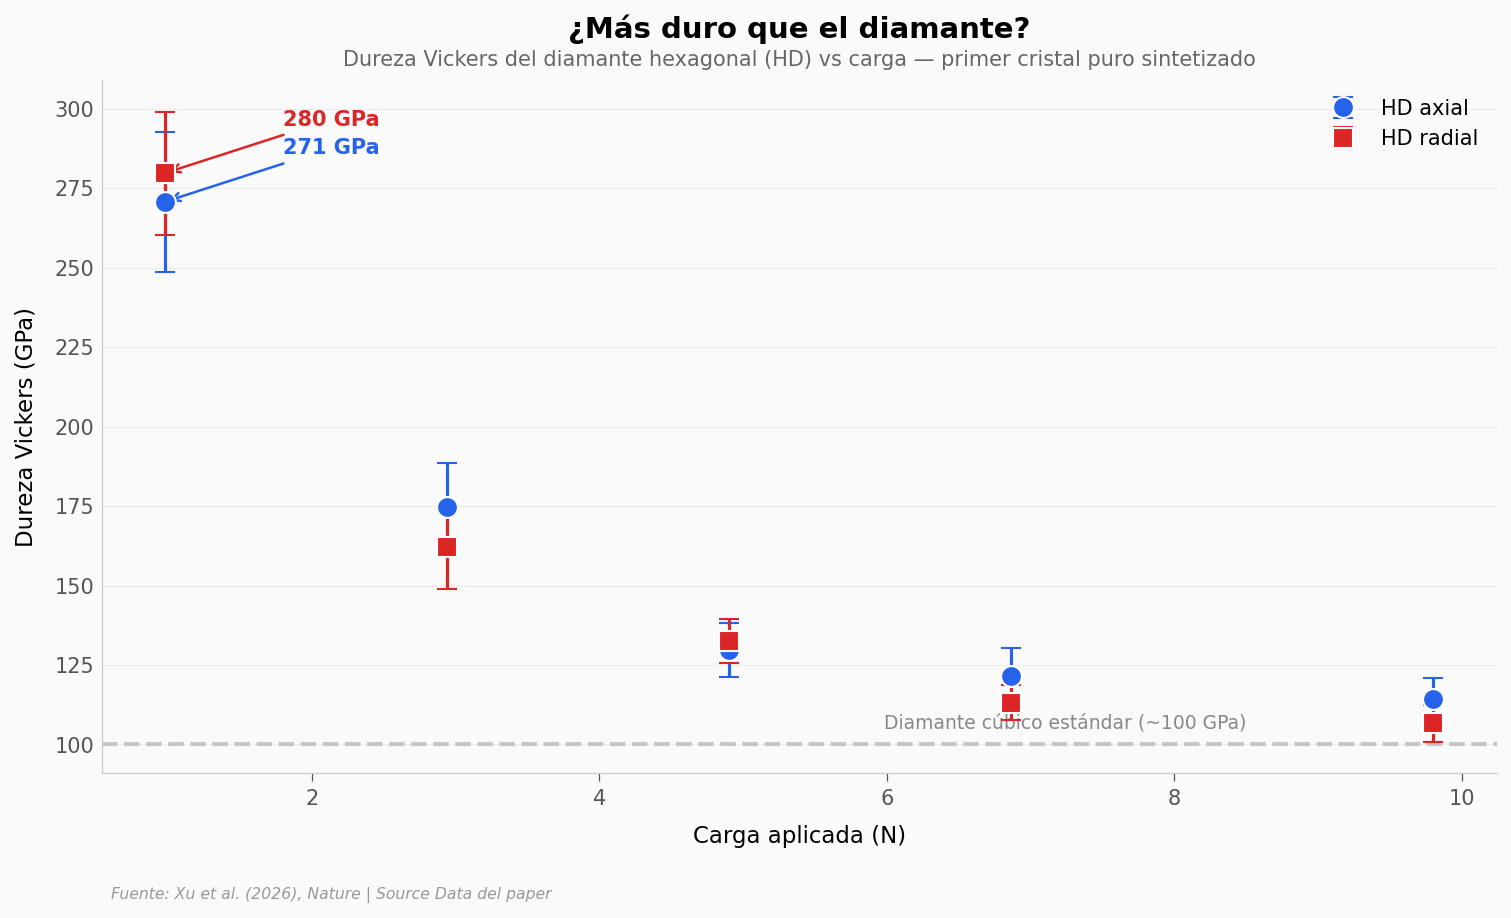

In [2]:
# ── Dureza Vickers del diamante hexagonal vs carga ──
axial = df_dureza[df_dureza['direction'] == 'axial']
radial = df_dureza[df_dureza['direction'] == 'radial']

fig, ax = plt.subplots(figsize=(12, 6))

# HD axial
ax.errorbar(axial['load_N'], axial['hardness_GPa'], yerr=axial['error_GPa'],
            fmt='o', color=COLOR_AXIAL, markersize=10, capsize=5, capthick=1.5,
            markeredgecolor='white', markeredgewidth=1, linewidth=1.5, zorder=5,
            label='HD axial')
# HD radial
ax.errorbar(radial['load_N'], radial['hardness_GPa'], yerr=radial['error_GPa'],
            fmt='s', color=COLOR_RADIAL, markersize=10, capsize=5, capthick=1.5,
            markeredgecolor='white', markeredgewidth=1, linewidth=1.5, zorder=5,
            label='HD radial')

# CD reference line
ax.axhline(y=DUREZA_CD_REF, color=COLOR_REF, linewidth=2, linestyle='--', alpha=0.8)
ax.text(8.5, DUREZA_CD_REF + 5, f'Diamante cúbico estándar (~{DUREZA_CD_REF} GPa)',
        fontsize=9, color='#888888', ha='right')

# Annotate max values
ax.annotate(f'{axial.iloc[0]["hardness_GPa"]:.0f} GPa',
            xy=(0.98, axial.iloc[0]['hardness_GPa']),
            xytext=(1.8, axial.iloc[0]['hardness_GPa'] + 15),
            fontsize=10, fontweight='bold', color=COLOR_AXIAL,
            arrowprops=dict(arrowstyle='->', color=COLOR_AXIAL, lw=1.2))
ax.annotate(f'{radial.iloc[0]["hardness_GPa"]:.0f} GPa',
            xy=(0.98, radial.iloc[0]['hardness_GPa']),
            xytext=(1.8, radial.iloc[0]['hardness_GPa'] + 15),
            fontsize=10, fontweight='bold', color=COLOR_RADIAL,
            arrowprops=dict(arrowstyle='->', color=COLOR_RADIAL, lw=1.2))

ax.set_xlabel('Carga aplicada (N)', fontsize=11)
ax.set_ylabel('Dureza Vickers (GPa)', fontsize=11)
ax.set_title('¿Más duro que el diamante?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Dureza Vickers del diamante hexagonal (HD) vs carga — primer cristal puro sintetizado',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/dureza_hd.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que revelan los datos

A la carga más baja (0,98 N), el diamante hexagonal alcanza **271 GPa (axial) y 280 GPa (radial)** — ambos por encima del diamante cúbico estándar. A medida que la carga sube, la dureza baja: es el **efecto de tamaño de indentación (ISE)**, común en materiales ultraduros. A 9,8 N, la dureza baja a 106–114 GPa, aún por encima de la referencia de 100 GPa del diamante cúbico.

A 0,98 N, la dirección radial es ligeramente más dura (280 vs 271 GPa), aunque a 2,94 N se invierte (162 vs 175 GPa) — una anisotropía variable con la carga, consistente con la estructura hexagonal.

## ¿Cómo saben que es diamante hexagonal y no cúbico?

La dureza alta no basta — hay que demostrar que los átomos están en la configuración hexagonal. La prueba: rayos X. Cada cristal deja una huella única.

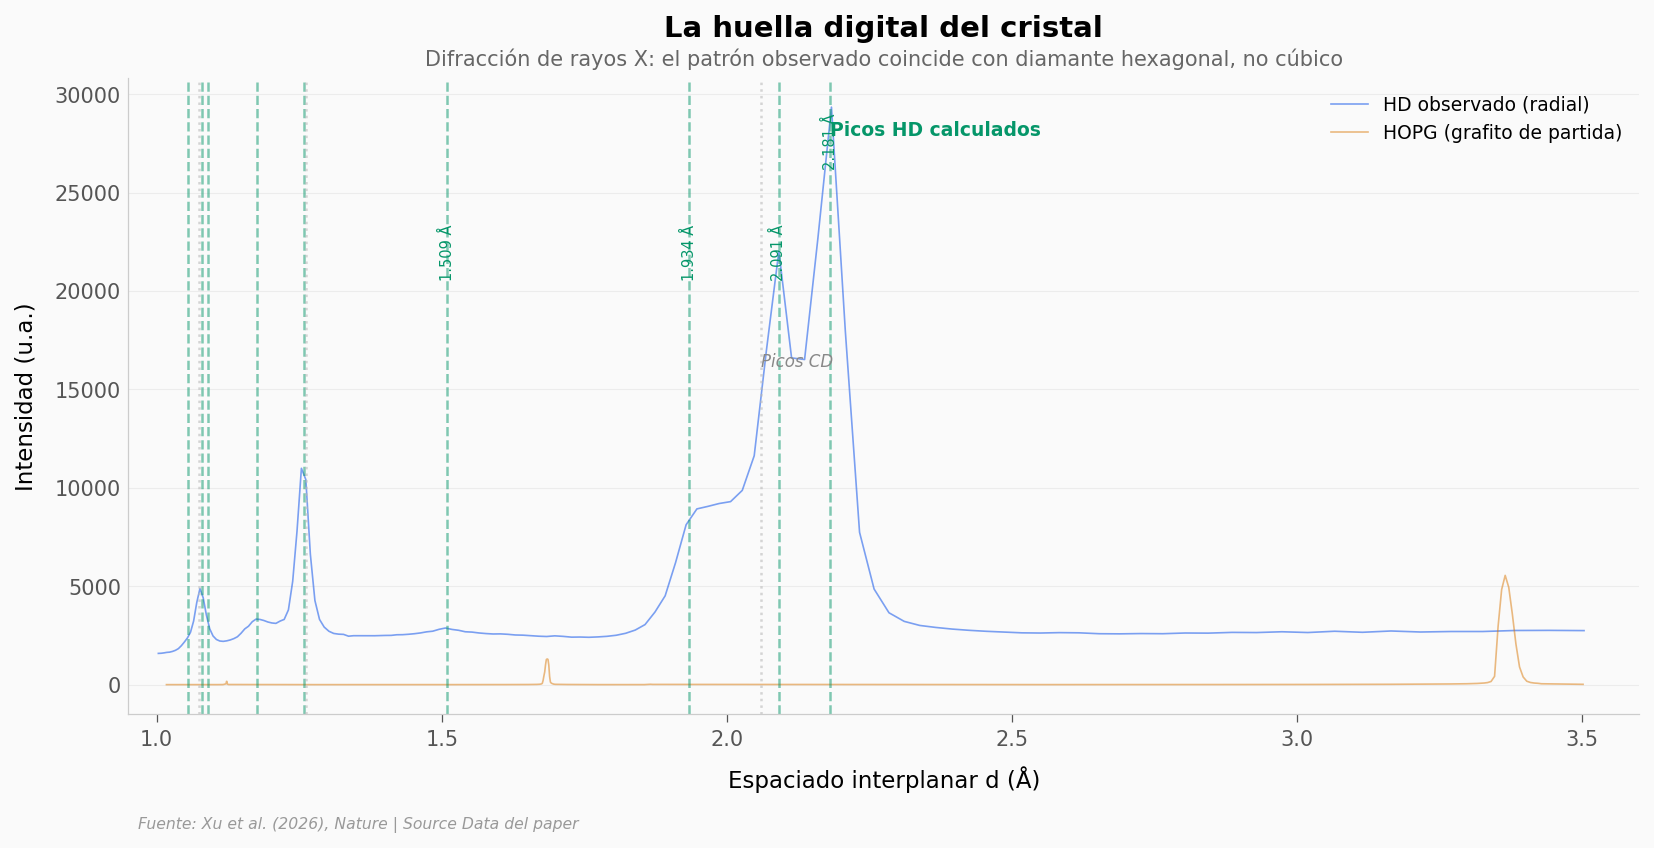

In [3]:
# ── Difracción de rayos X: HD observado vs calculado ──
fig, ax = plt.subplots(figsize=(13, 5.5))

# HD radial observed
hd_r = df_xrd.dropna(subset=['hd_radial_d'])
ax.plot(hd_r['hd_radial_d'], hd_r['hd_radial_intensity'],
        color=COLOR_AXIAL, alpha=0.6, linewidth=0.8, label='HD observado (radial)')

# HOPG observed
hopg = df_xrd.dropna(subset=['hopg_d'])
ax.plot(hopg['hopg_d'], hopg['hopg_intensity'],
        color=COLOR_HOPG, alpha=0.5, linewidth=0.8, label='HOPG (grafito de partida)')

# HD calculated peak positions (vertical lines)
hd_peaks = [2.181, 2.091, 1.934, 1.509, 1.259, 1.175, 1.090, 1.079, 1.055]
for i, d in enumerate(hd_peaks):
    ax.axvline(x=d, color=COLOR_HD, linewidth=1.2, linestyle='--', alpha=0.5)
    if i < 4:  # Label only first 4 peaks to avoid clutter
        ax.text(d, ax.get_ylim()[1]*0.85 if i == 0 else hd_r['hd_radial_intensity'].max()*0.7,
                f'{d:.3f} Å', fontsize=7, color=COLOR_HD, ha='center', rotation=90, va='bottom')

# CD calculated peaks
cd_peaks = [2.060, 1.261, 1.075]
for d in cd_peaks:
    ax.axvline(x=d, color=COLOR_REF, linewidth=1.2, linestyle=':', alpha=0.6)

# Labels for peak types
ax.text(2.181, hd_r['hd_radial_intensity'].max()*0.95,
        'Picos HD calculados', fontsize=9, color=COLOR_HD, fontweight='bold')
ax.text(2.060, hd_r['hd_radial_intensity'].max()*0.55,
        'Picos CD', fontsize=8, color='#888888', style='italic')

ax.set_xlabel('Espaciado interplanar d (Å)', fontsize=11)
ax.set_ylabel('Intensidad (u.a.)', fontsize=11)
ax.set_xlim(0.95, 3.6)
ax.set_title('La huella digital del cristal',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Difracción de rayos X: el patrón observado coincide con diamante hexagonal, no cúbico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=9, loc='upper right')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/xrd_patron.png', dpi=200, bbox_inches='tight')
plt.show()

### La huella es clara

Los picos observados coinciden con las posiciones calculadas para diamante hexagonal (líneas verdes discontinuas) y **no** con las del diamante cúbico (líneas grises punteadas). HD tiene 9 picos principales mientras que CD solo tiene 3 — la diferencia es inequívoca.

Pero ser duro no basta. ¿Qué pasa cuando lo calientas?

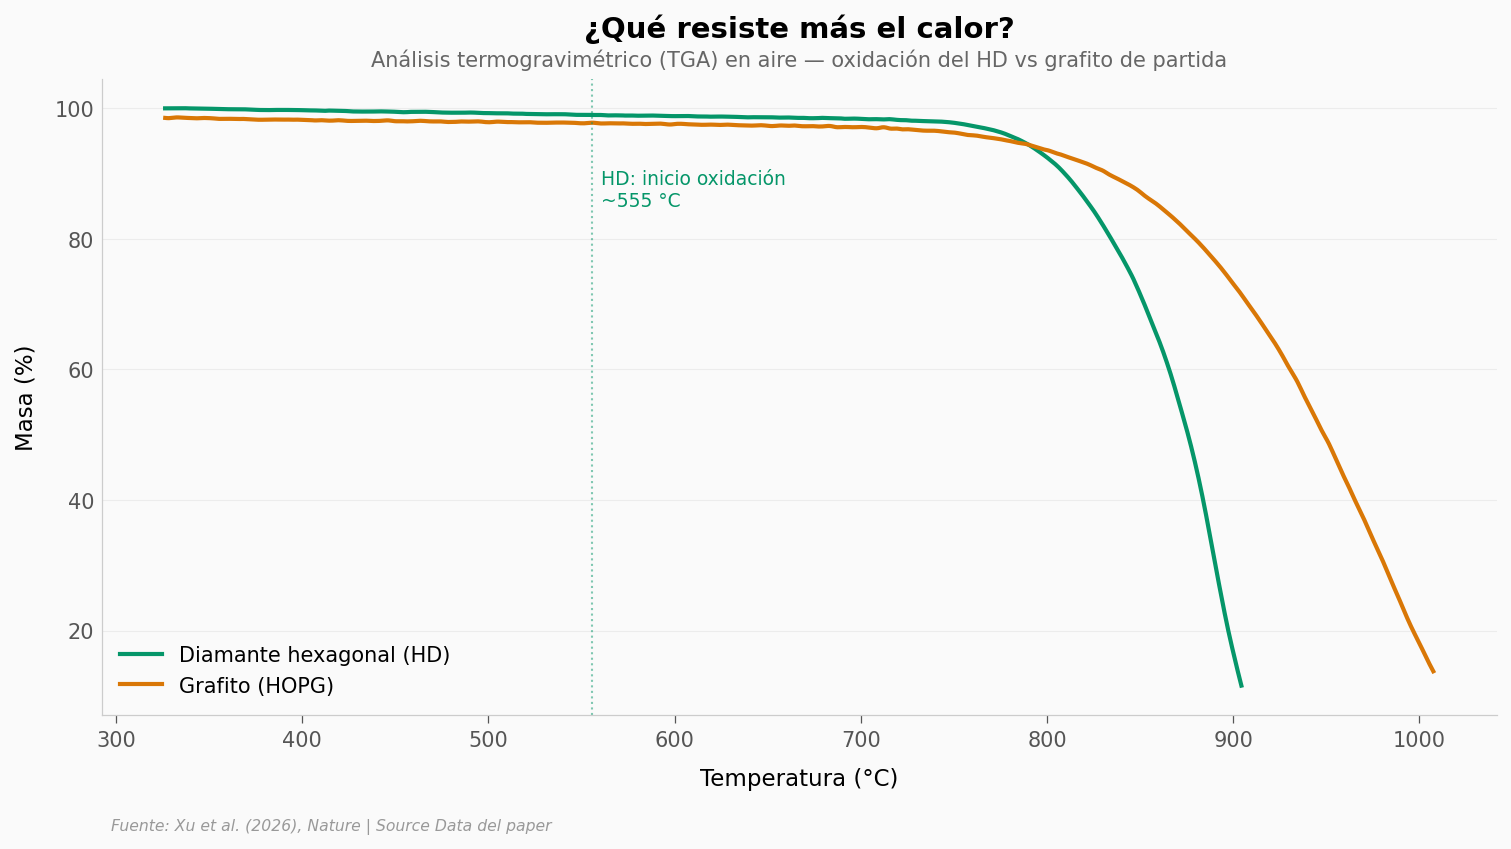

HD inicio oxidación (<99%): 555 °C (829 K)
HD masa final: 11.6% a 904 °C
HOPG masa final: 13.8% a 1007 °C


In [4]:
# ── Estabilidad térmica: HD vs HOPG (TGA en aire) ──
hd_tga = df_tga[df_tga['material'] == 'HD']
hopg_tga = df_tga[df_tga['material'] == 'HOPG']

fig, ax = plt.subplots(figsize=(12, 5.5))

ax.plot(hd_tga['temperature_K'] - 273.15, hd_tga['mass_pct'],
        color=COLOR_HD, linewidth=2, label='Diamante hexagonal (HD)')
ax.plot(hopg_tga['temperature_K'] - 273.15, hopg_tga['mass_pct'],
        color=COLOR_HOPG, linewidth=2, label='Grafito (HOPG)')

# Annotate key temperatures
hd_onset = hd_tga[hd_tga['mass_pct'] < 99]['temperature_K'].min() - 273.15
ax.axvline(x=hd_onset, color=COLOR_HD, linewidth=1, linestyle=':', alpha=0.5)
ax.text(hd_onset + 5, 85, f'HD: inicio oxidación\n~{hd_onset:.0f} °C',
        fontsize=9, color=COLOR_HD)

ax.set_xlabel('Temperatura (°C)', fontsize=11)
ax.set_ylabel('Masa (%)', fontsize=11)
ax.set_title('¿Qué resiste más el calor?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Análisis termogravimétrico (TGA) en aire — oxidación del HD vs grafito de partida',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='lower left')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/estabilidad_termica.png', dpi=200, bbox_inches='tight')
plt.show()

# Temperaturas clave
print(f"HD inicio oxidación (<99%): {hd_onset:.0f} °C ({hd_onset+273.15:.0f} K)")
hd_final = hd_tga.iloc[-1]
hopg_final = hopg_tga.iloc[-1]
print(f"HD masa final: {hd_final['mass_pct']:.1f}% a {hd_final['temperature_K']-273.15:.0f} °C")
print(f"HOPG masa final: {hopg_final['mass_pct']:.1f}% a {hopg_final['temperature_K']-273.15:.0f} °C")

### El diamante que no se rinde fácil

En aire, el HD empieza a oxidarse a ~556 °C. El grafito (HOPG) empieza con menos masa desde el inicio (~98,5%) y ambos terminan descompuestos. El punto no es que HD sea indestructible — ningún carbono lo es en aire a alta temperatura — sino que **arranca desde 100% de masa y se mantiene estable hasta ~556 °C**, mientras que el HOPG parte desde ~98,5%. Sin embargo, una vez que comienza la oxidación, el HD pierde masa más rápido que el HOPG (a 850 °C: HD 71% vs HOPG 87%).

¿Cuánto más duro es el HD respecto al diamante cúbico en cada carga?

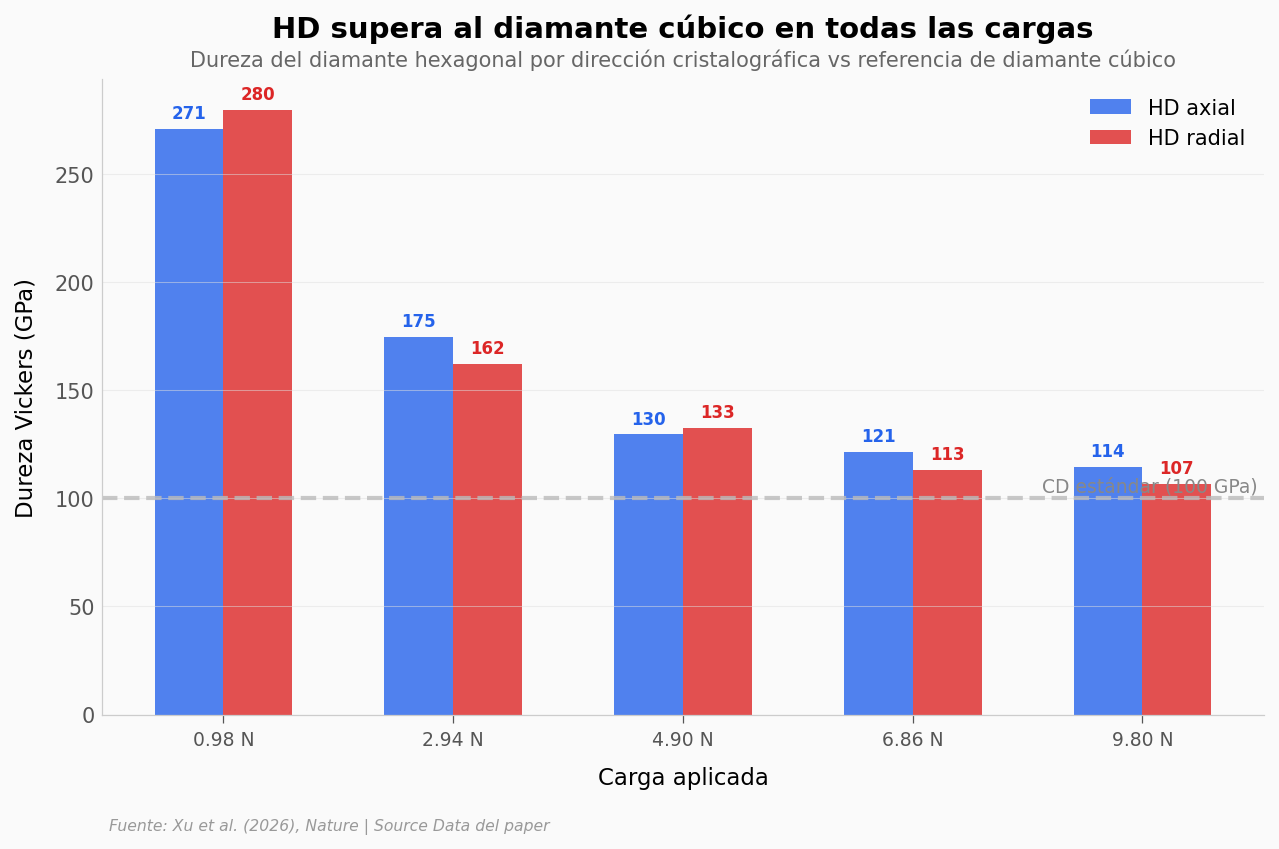

In [5]:
# ── Comparación de dureza: HD vs diamante cúbico estándar ──
fig, ax = plt.subplots(figsize=(10, 5.5))

loads = df_dureza[df_dureza['direction'] == 'axial']['load_N'].values
axial_h = df_dureza[df_dureza['direction'] == 'axial']['hardness_GPa'].values
radial_h = df_dureza[df_dureza['direction'] == 'radial']['hardness_GPa'].values

x = np.arange(len(loads))
w = 0.3

bars_ax = ax.bar(x - w/2, axial_h, w, color=COLOR_AXIAL, alpha=0.8, label='HD axial')
bars_rad = ax.bar(x + w/2, radial_h, w, color=COLOR_RADIAL, alpha=0.8, label='HD radial')

# CD reference
ax.axhline(y=DUREZA_CD_REF, color=COLOR_REF, linewidth=2, linestyle='--', alpha=0.8)
ax.text(len(loads) - 0.5, DUREZA_CD_REF + 3, f'CD estándar ({DUREZA_CD_REF} GPa)',
        fontsize=9, color='#888888', ha='right')

# Inline values
for i in range(len(loads)):
    ax.text(x[i] - w/2, axial_h[i] + 3, f'{axial_h[i]:.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color=COLOR_AXIAL)
    ax.text(x[i] + w/2, radial_h[i] + 3, f'{radial_h[i]:.0f}',
            ha='center', va='bottom', fontsize=8, fontweight='bold', color=COLOR_RADIAL)

ax.set_xticks(x)
ax.set_xticklabels([f'{l:.2f} N' for l in loads], fontsize=9)
ax.set_xlabel('Carga aplicada', fontsize=11)
ax.set_ylabel('Dureza Vickers (GPa)', fontsize=11)
ax.set_title('HD supera al diamante cúbico en todas las cargas',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Dureza del diamante hexagonal por dirección cristalográfica vs referencia de diamante cúbico',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')
ax.legend(fontsize=10, loc='upper right')

fig.text(0.13, -0.03, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/comparacion_dureza.png', dpi=200, bbox_inches='tight')
plt.show()

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| HD es más duro que CD | ✅ | A todas las cargas (0,98–9,8 N), HD > 100 GPa. A 0,98 N: 271–280 GPa vs ~100 GPa de CD estándar |
| Los picos XRD confirman estructura hexagonal | ✅ | 9 picos observados coinciden con HD calculado. No coinciden con las 3 posiciones de CD |
| HD es térmicamente estable hasta ~556 °C | ⚠️ | Masa >99% hasta 829 K (556 °C) en aire. Sobre esa temperatura, HD se oxida más rápido que el HOPG de partida |
| Primer HD puro a escala milimétrica | ⚠️ | El paper lo afirma; los datos confirman pureza (XRD sin picos de CD), pero el tamaño no se verifica con estos datos |

> **Limitaciones:** (1) La dureza Vickers depende fuertemente de la carga (ISE): los valores de 270–280 GPa son a 0,98 N. A cargas mayores (~10 N), la diferencia con CD es menor. (2) Los datos TGA son en aire (oxidación); la estabilidad en vacío o atmósfera inerte sería diferente. (3) No tenemos datos de dureza de CD medidos con el mismo equipo para comparación directa — el ~100 GPa es la referencia estándar.

## Ahora tú

1. **¿A qué carga se igualan?** Extrapola las curvas de dureza de HD. ¿A qué carga la dureza HD bajaría a ~100 GPa (el estándar de CD)?
2. **Compara las curvas TGA.** ¿A qué temperatura el HD pierde el 50% de su masa? ¿Y el HOPG?
3. **Busca los picos exclusivos.** HD tiene 9 picos y CD tiene 3. ¿Cuántos picos de HD NO coinciden con ninguno de CD?

In [6]:
# --- EXPERIMENTA AQUÍ ---
# ¿A qué temperatura HD y HOPG pierden el 50% de su masa?

for material, color in [('HD', COLOR_HD), ('HOPG', COLOR_HOPG)]:
    sub = df_tga[df_tga['material'] == material]
    half = sub[sub['mass_pct'] < 50]
    if len(half) > 0:
        t50 = half['temperature_K'].min() - 273.15
        print(f"{material}: 50% de masa a ~{t50:.0f} °C")
    else:
        print(f"{material}: no alcanza 50% en el rango medido (mín: {sub['mass_pct'].min():.1f}%)")

# Picos exclusivos de HD (que no coinciden con CD ± 0.02 Å)
hd_peaks = [2.181, 2.091, 1.934, 1.509, 1.259, 1.175, 1.090, 1.079, 1.055]
cd_peaks = [2.060, 1.261, 1.075]

print(f"\nPicos HD: {len(hd_peaks)}")
print(f"Picos CD: {len(cd_peaks)}")
exclusivos = [p for p in hd_peaks if all(abs(p - c) > 0.02 for c in cd_peaks)]
print(f"Picos exclusivos de HD: {len(exclusivos)} — {exclusivos}")

HD: 50% de masa a ~876 °C
HOPG: 50% de masa a ~949 °C

Picos HD: 9
Picos CD: 3
Picos exclusivos de HD: 6 — [2.181, 2.091, 1.934, 1.509, 1.175, 1.055]


---

**Paper:** Xu, C. et al. (2026). *Nature*. DOI: [10.1038/s41586-026-10212-4](https://doi.org/10.1038/s41586-026-10212-4)
**Datos:** Source Data (MOESM4) — difracción de rayos X, dureza Vickers, TGA
**Licencia datos:** [CC-BY 4.0](https://creativecommons.org/licenses/by/4.0/)
**Código:** [Ciencia a Mordiscos — El Lab](https://github.com/Ciencia-a-Mordiscos/lab)